
# Requirement 1 — Define the Biological Question
Biological topic
Escherichia coli and antimicrobial resistance
Biological question
What microorganisms, antimicrobial-resistance-related terms, resistance genes, antibiotics, and resistance mechanisms are most frequently discussed in PubMed literature related to Escherichia coli, and what relationships can be identified among these entities using dictionary-based named entity recognition and co-occurrence analysis?

Aim
The aim of this analysis is to use natural language processing (NLP) to characterize the biological concepts associated with Escherichia coli and antimicrobial resistance in PubMed abstracts.
Specifically, the analysis will:
1. Retrieve PubMed abstracts related to E. coli and antimicrobial/antibiotic resistance.
2. Explore the textual characteristics of the retrieved abstracts.
3. Clean, normalize, tokenize, and segment the text.
4. Represent the abstracts using Bag-of-Words (BoW) and TF-IDF.
5. Identify biological entities using dictionary-based named entity recognition (NER).
6. Identify relationships between biological entities through document-level co-occurrence analysis.
7. Evaluate the performance of the dictionary-based NER method.
8. Biologically validate important findings against published literature.
Why this question is biologically relevant
Antimicrobial resistance (AMR) is an important biological and public-health problem, and E. coli is frequently studied as a bacterial species associated with antimicrobial resistance. A text-mining approach can help identify recurring microorganisms, antibiotics, resistance genes, resistance mechanisms, and other biological concepts in the literature.
The analysis therefore combines bioinformatics, NLP, and biological interpretation to extract structured information from biomedical literature.


# REQUIREMENT 2: CHOOSE AN APPROPRIATE TEXT SOURCE


In [1]:


# We use PubMed as the text source because it contains
# peer-reviewed biomedical and life-science literature.

text_source = "PubMed"

# Biological topic of this project
biological_topic = (
    "Escherichia coli and antimicrobial/antibiotic resistance"
)

print("Text source:", text_source)
print("Biological topic:", biological_topic)

Text source: PubMed
Biological topic: Escherichia coli and antimicrobial/antibiotic resistance



# REQUIREMENT 3: RETRIEVE PUBMED ABSTRACTS USING BIOPYTHON


In [3]:


from Bio import Entrez, Medline
import pandas as pd
import numpy as np
import re
import itertools
from collections import Counter

# Tell NCBI who is making the request.
# Replace this with your preferred email if necessary.
Entrez.email = "dejeneseboka094@gmail.com"

# PubMed search query.
# We are looking specifically for Escherichia coli
# discussed together with antimicrobial/antibiotic resistance.
query = (
    '("Escherichia coli"[Title/Abstract]) AND '
    '("antimicrobial resistance"[Title/Abstract] OR '
    '"antibiotic resistance"[Title/Abstract])'
)

# Search PubMed.
# retmax=100 means we request up to 100 records.
search_handle = Entrez.esearch(
    db="pubmed",
    term=query,
    retmax=100
)

search_record = Entrez.read(search_handle)
search_handle.close()

# Retrieve the PMIDs returned by PubMed.
pmids = search_record["IdList"]

print("Total PubMed records found:", search_record["Count"])
print("Number of PMIDs retrieved:", len(pmids))
print("First 10 PMIDs:", pmids[:10])

# Verify that we have at least 50 abstracts.
if len(pmids) >= 50:
    print("\nRequirement 3 satisfied: at least 50 PMIDs retrieved.")
else:
    print("\nWARNING: Fewer than 50 PMIDs were retrieved.")

Total PubMed records found: 20839
Number of PMIDs retrieved: 100
First 10 PMIDs: ['42833102', '42831401', '42830652', '42830503', '42829764', '42829523', '42828735', '42828729', '42828091', '42827734']

Requirement 3 satisfied: at least 50 PMIDs retrieved.



# REQUIREMENT 4: RETRIEVE AND STORE REQUIRED METADATA


In [9]:


# Retrieve the complete MEDLINE records for the PMIDs.
fetch_handle = Entrez.efetch(
    db="pubmed",
    id=pmids,
    rettype="medline",
    retmode="text"
)

# Parse the MEDLINE records.
records = list(
    Medline.parse(fetch_handle)
)

fetch_handle.close()

print("Number of PubMed records retrieved:", len(records))

# Create a structured list containing the required fields.
data = []

for record in records:

    data.append({
        "PMID": record.get("PMID", ""),
        "Title": record.get("TI", ""),
        "Abstract": record.get("AB", ""),
        "Journal": record.get("JT", ""),
        "Year": record.get("DP", "")[:4]
    })

# Convert the records into a pandas DataFrame.
df = pd.DataFrame(data)

# Remove records that do not have an abstract.
df = df[
    df["Abstract"].notna() &
    df["Abstract"].str.strip().ne("")
].copy()

# Reset the DataFrame index.
df.reset_index(drop=True, inplace=True)

print("\nDataset shape:", df.shape)

# Display the first five records.
display(
    df[
        ["PMID", "Title", "Abstract", "Journal", "Year"]
    ].head()
)

# Check the required columns.
print("\nColumns:")
print(df.columns.tolist())

# Check missing values.
print("\nMissing values:")
print(df.isnull().sum())

Number of PubMed records retrieved: 100

Dataset shape: (100, 5)


,PMID,Title,Abstract,Journal,Year
0,42833102,Combating colistin- and cefotaxime-resistant S...,"Continuous monitoring of foodborne pathogens, ...",International journal of food microbiology,2026
1,42831401,Synthesis and Antibacterial Assessment of Nove...,&lt;b&gt;Background and Objective:&lt;/b&gt; A...,Pakistan journal of biological sciences : PJBS,2026
2,42830652,Iran's Escherichia coli AMR Landscape (2010-20...,Escherichia coli (E. coli) has developed resis...,MicrobiologyOpen,2026
3,42830503,Extended-spectrum beta-lactamase-producing Esc...,We extracted extended-spectrum beta-lactamase ...,The Journal of veterinary medical science,2026
4,42829764,"Clinical Characteristics, Microbial Profile, a...",Background and objective Recurrent urinary tra...,Cureus,2026



Columns:
['PMID', 'Title', 'Abstract', 'Journal', 'Year']

Missing values:
PMID        0
Title       0
Abstract    0
Journal     0
Year        0
dtype: int64



# REQUIREMENT 5: TEXT EXPLORATORY DATA ANALYSIS (EDA)


Number of abstracts: 100

Abstract length statistics:
count     100.00000
mean     1974.50000
std       515.22539
min       713.00000
25%      1623.00000
50%      1858.00000
75%      2275.00000
max      3405.00000
Name: abstract_length, dtype: float64

Word count statistics:
count    100.000000
mean     255.120000
std       66.779341
min       84.000000
25%      206.250000
50%      247.000000
75%      284.250000
max      471.000000
Name: raw_word_count, dtype: float64

Shortest abstracts:


,PMID,Title,raw_word_count
47,42797425,Halictine-II as a Potential Broad-Spectrum Ant...,84
3,42830503,Extended-spectrum beta-lactamase-producing Esc...,118
7,42828729,Discovery of dietary polyphenols targeting the...,153
21,42818832,Pilot longitudinal observational study of the ...,155
18,42820855,"OT-CATH, a conserved antimicrobial peptide in ...",162



Longest abstracts:


,PMID,Title,raw_word_count
61,42794108,Multidrug-Resistant Escherichia coli Harboring...,471
46,42797492,Pangenome-Guided In Silico Design and Structur...,407
89,42780744,"Pathogen distribution, antimicrobial resistanc...",396
28,42813778,Multidrug resistance and lipopolysaccharide re...,381
76,42791820,Curcumin Loaded ZIF 8 Nanomaterials Ameliorate...,371


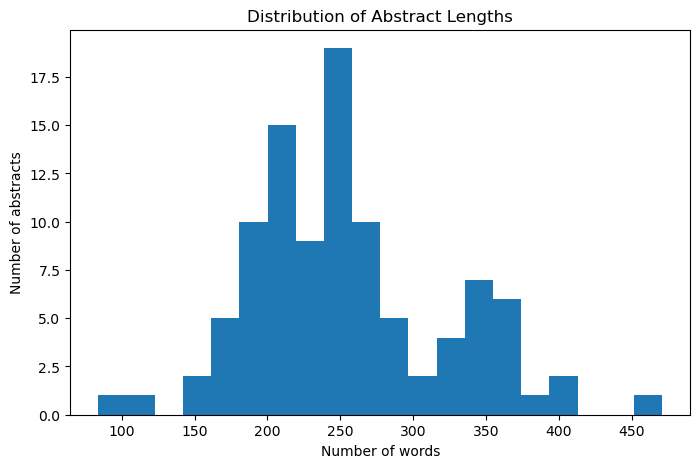


30 most frequent words:
[('and', 1151), ('the', 849), ('of', 672), ('in', 523), ('a', 372), ('to', 370), ('resistance', 295), ('with', 282), ('were', 249), ('coli', 238), ('was', 207), ('isolates', 203), ('for', 190), ('antimicrobial', 181), ('from', 156), ('e', 136), ('by', 132), ('as', 128), ('this', 127), ('that', 115), ('escherichia', 107), ('bacterial', 104), ('genes', 102), ('study', 101), ('resistant', 96), ('is', 95), ('these', 88), ('antibiotic', 87), ('associated', 84), ('an', 77)]


In [12]:


import matplotlib.pyplot as plt

# Calculate the number of characters in each abstract.
df["abstract_length"] = df["Abstract"].str.len()

# Calculate the approximate number of words in each abstract.
df["raw_word_count"] = (
    df["Abstract"]
    .str.split()
    .str.len()
)

# Display descriptive statistics.
print("Number of abstracts:", len(df))

print("\nAbstract length statistics:")
print(df["abstract_length"].describe())

print("\nWord count statistics:")
print(df["raw_word_count"].describe())

# Display the five shortest abstracts.
print("\nShortest abstracts:")
display(
    df[
        ["PMID", "Title", "raw_word_count"]
    ]
    .sort_values("raw_word_count")
    .head()
)

# Display the five longest abstracts.
print("\nLongest abstracts:")
display(
    df[
        ["PMID", "Title", "raw_word_count"]
    ]
    .sort_values(
        "raw_word_count",
        ascending=False
    )
    .head()
)

# Plot the distribution of abstract word counts.
plt.figure(figsize=(8, 5))

plt.hist(
    df["raw_word_count"],
    bins=20
)

plt.xlabel("Number of words")
plt.ylabel("Number of abstracts")
plt.title("Distribution of Abstract Lengths")

plt.show()

# Create a simple word-frequency analysis.
all_words = []

for text in df["Abstract"]:

    words = re.findall(
        r"\b[a-zA-Z]+\b",
        text.lower()
    )

    all_words.extend(words)

# Count word frequencies.
word_counts = Counter(all_words)

print("\n30 most frequent words:")
print(word_counts.most_common(30))


# REQUIREMENT 6: CLEAN AND NORMALIZE TEXT


In [15]:


def clean_text(text):
    """
    Clean and normalize biomedical abstract text.

    Operations:
    1. Convert text to lowercase.
    2. Remove HTML/XML-like tags.
    3. Replace non-alphanumeric characters with spaces.
    4. Normalize repeated whitespace.
    """

    # Convert to string.
    text = str(text)

    # Convert to lowercase.
    text = text.lower()

    # Remove HTML/XML tags.
    text = re.sub(
        r"<[^>]+>",
        " ",
        text
    )

    # Replace punctuation and special characters with spaces.
    text = re.sub(
        r"[^a-z0-9\s]",
        " ",
        text
    )

    # Replace multiple spaces with one space.
    text = re.sub(
        r"\s+",
        " ",
        text
    )

    # Remove leading/trailing whitespace.
    return text.strip()


# Apply the cleaning function to all abstracts.
df["clean_text"] = df["Abstract"].apply(
    clean_text
)

# Compare original and cleaned text.
print("ORIGINAL TEXT:\n")
print(df["Abstract"].iloc[0])

print("\n\nCLEANED TEXT:\n")
print(df["clean_text"].iloc[0])

ORIGINAL TEXT:

Continuous monitoring of foodborne pathogens, especially multidrug-resistant (MDR) bacteria, is crucial for the food industry, healthcare, and regulatory agencies. This study assessed the prevalence, antimicrobial resistance, and virulence genes (stx1, stx2, and eaeA) in Escherichia coli strains isolated from milk and dairy-based products. In addition, the inhibitory activity of epsilon-poly-L-lysine (epsilon-PL) against E. coli O(26):H(11)in vitro and in vivo (ice cream and cheese) was evaluated for the first time. A total of 300 samples, including market raw milk, pasteurized milk, Kariesh cheese, Damietta cheese, ice cream, and yoghurt (50 samples of each product), were analyzed. The results revealed that Kariesh cheese had the highest E. coli prevalence rate at 28%, followed by ice cream, market raw milk, and Damietta cheese at 24%, 22%, and 14%, respectively. The serological identification revealed that the isolates (n=88) belonged to 4 different pathotypes. Surpri

# REQUIREMENT 7: SENTENCE SEGMENTATION

In [81]:
# REQUIREMENT 7: SENTENCE SEGMENTATION

import re
import nltk
from nltk.tokenize import sent_tokenize

# Download the required NLTK sentence-tokenization resources
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

# Use the original Abstract column so that sentence-ending punctuation
# has not been removed by the previous cleaning step.
# We only normalize whitespace and remove simple HTML tags/entities.
def prepare_for_sentence_segmentation(text):
    # Convert missing values to an empty string
    text = str(text)

    # Remove simple HTML tags if present
    text = re.sub(r"<[^>]+>", " ", text)

    # Replace common HTML entities
    text = text.replace("&nbsp;", " ")
    text = text.replace("&amp;", "&")

    # Normalize repeated whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # IMPORTANT:
    # Do NOT remove ".", "?", or "!" because NLTK needs
    # sentence-ending punctuation for sentence segmentation.
    return text


# Prepare the abstracts for sentence segmentation
df["Segmentation_Text"] = df["Abstract"].apply(
    prepare_for_sentence_segmentation
)

# Segment every abstract into individual sentences
df["Sentences"] = df["Segmentation_Text"].apply(
    lambda text: sent_tokenize(text)
)

# Count the number of sentences in each abstract
df["Sentence_Count"] = df["Sentences"].apply(len)


# Display the segmented sentences from the first abstract
print("SENTENCE SEGMENTATION OF THE FIRST ABSTRACT")
print("=" * 60)

for i, sentence in enumerate(df.loc[0, "Sentences"], start=1):
    print(f"{i}. {sentence}")


# Display sentence-count statistics
print("\nSENTENCE COUNT STATISTICS")
print("=" * 60)

print(df["Sentence_Count"].describe())


# Display the first few sentence counts
print("\nFIRST 10 ABSTRACTS - SENTENCE COUNTS")
print("=" * 60)

print(
    df[["PMID", "Sentence_Count"]]
    .head(10)
    .to_string(index=False)
)


# Check whether all abstracts were segmented into more than one sentence
print("\nSEGMENTATION CHECK")
print("=" * 60)

print("Total abstracts:", len(df))
print("Abstracts with more than one sentence:",
      (df["Sentence_Count"] > 1).sum())
print("Abstracts with exactly one sentence:",
      (df["Sentence_Count"] == 1).sum())

SENTENCE SEGMENTATION OF THE FIRST ABSTRACT
1. Continuous monitoring of foodborne pathogens, especially multidrug-resistant (MDR) bacteria, is crucial for the food industry, healthcare, and regulatory agencies.
2. This study assessed the prevalence, antimicrobial resistance, and virulence genes (stx1, stx2, and eaeA) in Escherichia coli strains isolated from milk and dairy-based products.
3. In addition, the inhibitory activity of epsilon-poly-L-lysine (epsilon-PL) against E. coli O(26):H(11)in vitro and in vivo (ice cream and cheese) was evaluated for the first time.
4. A total of 300 samples, including market raw milk, pasteurized milk, Kariesh cheese, Damietta cheese, ice cream, and yoghurt (50 samples of each product), were analyzed.
5. The results revealed that Kariesh cheese had the highest E. coli prevalence rate at 28%, followed by ice cream, market raw milk, and Damietta cheese at 24%, 22%, and 14%, respectively.
6. The serological identification revealed that the isolates (n=


# REQUIREMENT 8: TOKENIZATION


In [21]:

from nltk.tokenize import word_tokenize

# Tokenize every cleaned abstract into individual words/tokens.
df["tokens"] = df["clean_text"].apply(
    word_tokenize
)

# Count tokens in each abstract.
df["token_count"] = df["tokens"].apply(
    len
)

# Display the first 50 tokens from the first abstract.
print("First 50 tokens:\n")

print(
    df["tokens"].iloc[0][:50]
)

# Display token-count statistics.
print("\nToken count statistics:")
print(df["token_count"].describe())

First 50 tokens:

['continuous', 'monitoring', 'of', 'foodborne', 'pathogens', 'especially', 'multidrug', 'resistant', 'mdr', 'bacteria', 'is', 'crucial', 'for', 'the', 'food', 'industry', 'healthcare', 'and', 'regulatory', 'agencies', 'this', 'study', 'assessed', 'the', 'prevalence', 'antimicrobial', 'resistance', 'and', 'virulence', 'genes', 'stx1', 'stx2', 'and', 'eaea', 'in', 'escherichia', 'coli', 'strains', 'isolated', 'from', 'milk', 'and', 'dairy', 'based', 'products', 'in', 'addition', 'the', 'inhibitory', 'activity']

Token count statistics:
count    100.000000
mean     274.090000
std       72.782656
min       93.000000
25%      219.000000
50%      262.000000
75%      315.250000
max      512.000000
Name: token_count, dtype: float64



# REQUIREMENT 9: BAG-OF-WORDS AND TF-IDF


In [24]:


from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# ------------------------------------------------------------
# BAG-OF-WORDS
# ------------------------------------------------------------

# Create the Bag-of-Words vectorizer.
bow_vectorizer = CountVectorizer(
    stop_words="english"
)

# Transform the abstracts into a BoW matrix.
X_bow = bow_vectorizer.fit_transform(
    df["clean_text"]
)

# Get the BoW vocabulary.
bow_terms = (
    bow_vectorizer
    .get_feature_names_out()
)

print("BoW matrix shape:", X_bow.shape)
print("BoW vocabulary size:", len(bow_terms))

# Calculate total frequency of every word across documents.
bow_counts = np.asarray(
    X_bow.sum(axis=0)
).ravel()

# Find the 30 most frequent BoW terms.
top_indices = (
    bow_counts
    .argsort()[::-1][:30]
)

bow_frequency = pd.DataFrame({
    "Term": bow_terms[top_indices],
    "Frequency": bow_counts[top_indices]
})

print("\nMost frequent BoW terms:")
display(bow_frequency)


# ------------------------------------------------------------
# TF-IDF
# ------------------------------------------------------------

# Create the TF-IDF vectorizer.
tfidf_vectorizer = TfidfVectorizer(
    stop_words="english"
)

# Transform the abstracts into a TF-IDF matrix.
X_tfidf = tfidf_vectorizer.fit_transform(
    df["clean_text"]
)

# Get the TF-IDF vocabulary.
tfidf_terms = (
    tfidf_vectorizer
    .get_feature_names_out()
)

print("\nTF-IDF matrix shape:", X_tfidf.shape)
print("TF-IDF vocabulary size:", len(tfidf_terms))

# Calculate the mean TF-IDF score for each term.
tfidf_scores = np.asarray(
    X_tfidf.mean(axis=0)
).ravel()

# Find the 30 terms with the highest average TF-IDF.
top_indices = (
    tfidf_scores
    .argsort()[::-1][:30]
)

tfidf_top = pd.DataFrame({
    "Term": tfidf_terms[top_indices],
    "Mean_TFIDF": tfidf_scores[top_indices]
})

print("\nTop TF-IDF terms:")
display(tfidf_top)

BoW matrix shape: (100, 4371)
BoW vocabulary size: 4371

Most frequent BoW terms:


,Term,Frequency
0,resistance,295
1,coli,238
2,isolates,203
3,antimicrobial,181
4,escherichia,107
5,bacterial,104
6,genes,102
7,study,101
8,resistant,96
9,antibiotic,87



TF-IDF matrix shape: (100, 4371)
TF-IDF vocabulary size: 4371

Top TF-IDF terms:


,Term,Mean_TFIDF
0,isolates,0.051290
1,resistance,0.049848
2,coli,0.035743
3,antimicrobial,0.033254
4,genes,0.028105
5,bacterial,0.025943
6,antibiotic,0.025616
7,resistant,0.024618
8,esbl,0.022107
9,susceptibility,0.021903



# REQUIREMENT 10: NLP TASK


In [27]:


# The NLP task selected for this project is:
#
# Dictionary-based biomedical Named Entity Recognition (NER).
#
# NER will identify:
#   - microorganisms
#   - antibiotics
#   - resistance genes
#   - resistance mechanisms
#   - resistance-related terms
#   - other biological terms

nlp_task = "Dictionary-based biomedical Named Entity Recognition"

print("NLP task:", nlp_task)

NLP task: Dictionary-based biomedical Named Entity Recognition



# REQUIREMENT 11: DICTIONARY-BASED NER


In [61]:


import re
from collections import Counter

# ------------------------------------------------------------
# 1. Define a refined biological entity dictionary
# ------------------------------------------------------------
# The dictionary focuses on specific and biologically meaningful
# entities rather than very generic words such as "gene",
# "genes", "resistance", "strain", "isolates", etc.
#
# Longer terms are matched before shorter terms to reduce
# incorrect partial matches.

entity_dictionary_refined = {

    # --------------------------------------------------------
    # MICROORGANISMS
    # --------------------------------------------------------
    "MICROORGANISM": [
        "Escherichia coli",
        "E. coli",
        "Escherichia",
        "Klebsiella pneumoniae",
        "Klebsiella",
        "Pseudomonas aeruginosa",
        "Pseudomonas",
        "Acinetobacter baumannii",
        "Acinetobacter",
        "Staphylococcus aureus",
        "Staphylococcus epidermidis",
        "Staphylococcus",
        "Enterococcus faecium",
        "Enterococcus faecalis",
        "Enterococcus",
        "Salmonella enterica",
        "Salmonella",
        "Shigella",
        "Enterobacter",
        "Enterobacterales",
        "Proteus mirabilis",
        "Proteus",
        "Citrobacter",
        "Serratia",
        "Bacillus cereus",
        "Cronobacter malonaticus",
        "Delftia acidovorans",
        "Clostridium butyricum",
        "Lactiplantibacillus plantarum",
        "Streptococcus pneumoniae",
        "Streptococcus viridans",
        "Streptococcus",
        "Aspergillus niger",
        "Penicillium solitum"
    ],

    # --------------------------------------------------------
    # ANTIBIOTICS
    # --------------------------------------------------------
    # Generic words such as "antibiotic" and "antimicrobial"
    # are intentionally excluded.
    "ANTIBIOTIC": [
        "ampicillin",
        "amoxicillin",
        "penicillin",
        "polymyxin B",
        "polymyxin",
        "cephalosporin",
        "ceftriaxone",
        "cefotaxime",
        "ceftazidime",
        "cefepime",
        "meropenem",
        "imipenem",
        "ertapenem",
        "doripenem",
        "ciprofloxacin",
        "levofloxacin",
        "ofloxacin",
        "tetracycline",
        "doxycycline",
        "gentamicin",
        "amikacin",
        "streptomycin",
        "azithromycin",
        "erythromycin",
        "chloramphenicol",
        "trimethoprim",
        "sulfamethoxazole",
        "vancomycin",
        "colistin",
        "enrofloxacin",
        "beta-lactam antibiotics"
    ],

    # --------------------------------------------------------
    # RESISTANCE GENES
    # --------------------------------------------------------
    # Ambiguous short terms such as "cat", "aac", "aad",
    # "aph" and "qnr" alone are excluded because they can
    # generate false positives.
    "RESISTANCE_GENE": [
        "blaTEM",
        "blaTEM-1B",
        "blaSHV",
        "blaCTX-M",
        "blaCTX-M-1",
        "blaCTX-M-14",
        "blaCTX-M-15",
        "blaCTX-M-55",
        "blaCTXM",
        "blaKPC",
        "blaNDM",
        "blaOXA",
        "blaVIM",
        "blaIMP",
        "mecA",
        "vanA",
        "vanB",
        "tetA",
        "tetB",
        "tetM",
        "sul1",
        "sul2",
        "dfrA",
        "ermB",
        "ermC",
        "acrB",
        "marA",
        "mcr-1",
        "mcr1",
        "mcr",
        "qnrS",
        "aac(6')-Ib-cr",
        "arnBCADTEF",
        "antibiotic resistance genes",
        "antimicrobial resistance genes",
        "ARGs"
    ],

    # --------------------------------------------------------
    # RESISTANCE MECHANISMS
    # --------------------------------------------------------
    "RESISTANCE_MECHANISM": [
        "extended-spectrum beta-lactamase",
        "extended-spectrum beta-lactamases",
        "beta-lactamase",
        "beta lactamase",
        "ESBL",
        "carbapenemase",
        "carbapenemases",
        "efflux pump",
        "efflux pumps",
        "enzymatic degradation",
        "target modification",
        "target alteration",
        "reduced permeability",
        "membrane permeability",
        "porin loss",
        "biofilm formation",
        "antibiotic inactivation",
        "drug inactivation",
        "horizontal gene transfer",
        "plasmid-mediated resistance",
        "quorum sensing"
    ],

    # --------------------------------------------------------
    # RESISTANCE TERMS
    # --------------------------------------------------------
    # Generic "resistance" and "resistant" are excluded because
    # they occur extremely frequently and are not specific
    # enough for useful entity-level analysis.
    "RESISTANCE_TERM": [
        "antibiotic resistance",
        "antimicrobial resistance",
        "multidrug resistance",
        "multidrug-resistant",
        "multi-drug resistant",
        "drug resistance",
        "polymyxin resistance",
        "antibiotic susceptibility",
        "antimicrobial susceptibility",
        "antibiotic-associated dysbiosis",
        "MDR bacteria"
    ],

    # --------------------------------------------------------
    # BIOLOGICAL TERMS
    # --------------------------------------------------------
    # Only specific biological concepts are retained.
    # Generic words such as "gene", "genes", "protein",
    # "sequence", "strain", "isolate", "DNA", and "RNA"
    # are intentionally removed.
    "BIOLOGICAL_TERM": [
        "Shiga toxin",
        "Shiga-like toxin",
        "botulinum neurotoxin",
        "virulence genes",
        "biofilm",
        "biofilms",
        "gene expression",
        "ST131",
        "ST131-B",
        "ST131-C",
        "LPS",
        "lipopolysaccharide",
        "bacterial membrane",
        "bacterial respiratory chain"
    ]
}


# ------------------------------------------------------------
# 2. Dictionary-based NER function
# ------------------------------------------------------------
def dictionary_ner(text, entity_dictionary):

    entities = []
    occupied_spans = []

    # Create a single list containing every entity and category
    terms = []

    for category, entity_list in entity_dictionary.items():
        for entity in entity_list:
            terms.append((entity, category))

    # Match longer terms first.
    # Example:
    # "extended-spectrum beta-lactamase" is checked before
    # "beta-lactamase".
    terms = sorted(
        terms,
        key=lambda x: len(x[0]),
        reverse=True
    )

    text_lower = text.lower()

    # Search for every dictionary term
    for entity, category in terms:

        entity_lower = entity.lower()

        # Case-insensitive exact phrase matching
        pattern = r"\b" + re.escape(entity_lower) + r"\b"

        matches = re.finditer(pattern, text_lower)

        for match in matches:

            start, end = match.span()

            # Check whether this entity overlaps with an entity
            # that has already been detected.
            overlap = any(
                start < existing_end and
                end > existing_start
                for existing_start, existing_end in occupied_spans
            )

            if overlap:
                continue

            # Store the entity exactly as it appears in the text
            entities.append({
                "entity": text[start:end],
                "category": category,
                "start": start,
                "end": end
            })

            occupied_spans.append((start, end))

    # Sort entities according to their position in the abstract
    entities.sort(key=lambda x: x["start"])

    return entities


# ------------------------------------------------------------
# 3. Apply the refined NER to all PubMed abstracts
# ------------------------------------------------------------
df["named_entities_refined"] = df["Abstract"].apply(
    lambda text: dictionary_ner(
        text,
        entity_dictionary_refined
    )
)


# ------------------------------------------------------------
# 4. Count the number of detected entities per abstract
# ------------------------------------------------------------
df["entity_count"] = df["named_entities_refined"].apply(len)


# ------------------------------------------------------------
# 5. Calculate overall NER statistics
# ------------------------------------------------------------
total_entities = sum(df["entity_count"])

abstracts_with_entities = (
    df["entity_count"] > 0
).sum()

abstracts_without_entities = (
    df["entity_count"] == 0
).sum()


print("============================================================")
print("REQUIREMENT 11 — DICTIONARY-BASED NER")
print("============================================================")

print(f"Number of PubMed abstracts: {len(df)}")
print(f"Total entities detected: {total_entities}")
print(f"Abstracts containing at least one entity: {abstracts_with_entities}")
print(f"Abstracts containing no entities: {abstracts_without_entities}")


# ------------------------------------------------------------
# 6. Count entities by category
# ------------------------------------------------------------
category_counts = Counter()

for entities in df["named_entities_refined"]:
    for item in entities:
        category_counts[item["category"]] += 1


print("\nENTITY COUNTS BY CATEGORY")
print("--------------------------------------------")

for category, count in category_counts.most_common():
    print(f"{category:25s}: {count}")


# ------------------------------------------------------------
# 7. Display the most frequently detected entities
# ------------------------------------------------------------
entity_counts = Counter()

for entities in df["named_entities_refined"]:
    for item in entities:
        entity_key = (
            item["entity"],
            item["category"]
        )
        entity_counts[entity_key] += 1


print("\nTOP 30 DETECTED ENTITIES")
print("--------------------------------------------")

for (entity, category), count in entity_counts.most_common(30):
    print(
        f"{entity:40s} | "
        f"{category:25s} | "
        f"{count}"
    )


# ------------------------------------------------------------
# 8. Display example NER results
# ------------------------------------------------------------
print("\nEXAMPLE NER RESULTS")
print("============================================================")

for _, row in df.head(5).iterrows():

    print(f"\nPMID: {row['PMID']}")
    print(f"Title: {row['Title']}")

    if row["named_entities_refined"]:
        for item in row["named_entities_refined"]:
            print(
                f"  {item['entity']} "
                f"--> {item['category']}"
            )
    else:
        print("  No entities detected")


# ------------------------------------------------------------
# 9. Store a simplified entity representation
# ------------------------------------------------------------
# This column will be useful for Requirement 12
# (co-occurrence analysis).

df["entities_for_analysis"] = df[
    "named_entities_refined"
].apply(
    lambda entities: [
        (
            item["entity"],
            item["category"]
        )
        for item in entities
    ]
)


print("\n============================================================")
print("Requirement 11 completed.")
print("The refined NER results are stored in:")
print("  df['named_entities_refined']")
print("  df['entities_for_analysis']")
print("  df['entity_count']")
print("============================================================")

REQUIREMENT 11 — DICTIONARY-BASED NER
Number of PubMed abstracts: 100
Total entities detected: 1008
Abstracts containing at least one entity: 100
Abstracts containing no entities: 0

ENTITY COUNTS BY CATEGORY
--------------------------------------------
MICROORGANISM            : 421
RESISTANCE_TERM          : 172
ANTIBIOTIC               : 149
RESISTANCE_MECHANISM     : 120
RESISTANCE_GENE          : 86
BIOLOGICAL_TERM          : 60

TOP 30 DETECTED ENTITIES
--------------------------------------------
E. coli                                  | MICROORGANISM             | 130
Escherichia coli                         | MICROORGANISM             | 104
antimicrobial resistance                 | RESISTANCE_TERM           | 68
ESBL                                     | RESISTANCE_MECHANISM      | 56
Staphylococcus aureus                    | MICROORGANISM             | 27
multidrug-resistant                      | RESISTANCE_TERM           | 26
mcr-1                                    | RE


# REQUIREMENT 12: ENTITY CO-OCCURRENCE ANALYSIS


In [68]:


from itertools import combinations
from collections import Counter
import pandas as pd


# ------------------------------------------------------------
# 1. Define canonical entity normalization
# ------------------------------------------------------------
# Different textual forms of the same biological entity are
# mapped to one canonical representation.
#
# Example:
#   "E. coli"            -> "Escherichia coli"
#   "Antimicrobial resistance" -> "antimicrobial resistance"
#
# This prevents the same biological entity from being counted
# as multiple different entities.

entity_normalization = {

    # Microorganisms
    "e. coli": "Escherichia coli",
    "escherichia coli": "Escherichia coli",
    "escherichia": "Escherichia",

    "klebsiella": "Klebsiella",
    "klebsiella pneumoniae": "Klebsiella pneumoniae",

    "pseudomonas": "Pseudomonas",
    "pseudomonas aeruginosa": "Pseudomonas aeruginosa",

    "acinetobacter": "Acinetobacter",
    "acinetobacter baumannii": "Acinetobacter baumannii",

    "staphylococcus": "Staphylococcus",
    "staphylococcus aureus": "Staphylococcus aureus",
    "staphylococcus epidermidis": "Staphylococcus epidermidis",

    "enterococcus": "Enterococcus",
    "enterococcus faecium": "Enterococcus faecium",
    "enterococcus faecalis": "Enterococcus faecalis",

    "salmonella": "Salmonella",
    "salmonella enterica": "Salmonella enterica",

    "streptococcus": "Streptococcus",
    "streptococcus pneumoniae": "Streptococcus pneumoniae",
    "streptococcus viridans": "Streptococcus viridans",

    # Resistance terms
    "antimicrobial resistance": "antimicrobial resistance",
    "antibiotic resistance": "antibiotic resistance",
    "antimicrobial susceptibility": "antimicrobial susceptibility",
    "multidrug-resistant": "multidrug-resistant",
    "multi-drug resistant": "multidrug-resistant",
    "multidrug resistance": "multidrug resistance",

    # Resistance mechanisms
    "esbl": "ESBL",
    "extended-spectrum beta-lactamase":
        "extended-spectrum beta-lactamase",
    "extended-spectrum beta-lactamases":
        "extended-spectrum beta-lactamase",

    "beta-lactamase": "beta-lactamase",
    "beta lactamase": "beta-lactamase",

    "carbapenemase": "carbapenemase",
    "carbapenemases": "carbapenemase",

    # Resistance genes
    "mcr": "mcr",
    "mcr-1": "mcr-1",
    "blactx-m": "blaCTX-M",
    "blactx-m-1": "blaCTX-M-1",
    "blactx-m-14": "blaCTX-M-14",
    "blactx-m-15": "blaCTX-M-15",
    "blactx-m-55": "blaCTX-M-55",

    # Antibiotics
    "colistin": "colistin",
    "polymyxin": "polymyxin",
    "polymyxin b": "polymyxin B",
    "ciprofloxacin": "ciprofloxacin",
    "tetracycline": "tetracycline",
    "gentamicin": "gentamicin",
    "vancomycin": "vancomycin",
    "cephalosporin": "cephalosporin"
}


# ------------------------------------------------------------
# 2. Normalize an individual entity
# ------------------------------------------------------------
def normalize_entity(entity):
    """
    Convert different textual representations of an entity
    into a canonical representation.
    """

    entity_clean = entity.strip()

    # Case-insensitive lookup
    key = entity_clean.lower()

    if key in entity_normalization:
        return entity_normalization[key]

    # Preserve the original spelling when no explicit
    # normalization rule is required.
    return entity_clean


# ------------------------------------------------------------
# 3. Create normalized entity lists for every abstract
# ------------------------------------------------------------
def get_normalized_entities(entity_list):

    normalized = []

    for item in entity_list:

        canonical_entity = normalize_entity(
            item["entity"]
        )

        normalized.append(
            (
                canonical_entity,
                item["category"]
            )
        )

    return normalized


df["normalized_entities"] = df[
    "named_entities_refined"
].apply(get_normalized_entities)


# ------------------------------------------------------------
# 4. Remove duplicate mentions within each abstract
# ------------------------------------------------------------
# Co-occurrence is measured at the DOCUMENT level.
#
# If "E. coli" occurs five times in one abstract, it should
# still count as one entity for that abstract's co-occurrence
# relationships.

df["unique_normalized_entities"] = df[
    "normalized_entities"
].apply(
    lambda entities: sorted(
        set(entities),
        key=lambda x: (x[1], x[0].lower())
    )
)


# ------------------------------------------------------------
# 5. Generate entity pairs within each abstract
# ------------------------------------------------------------
cooccurrence_counter = Counter()

for _, row in df.iterrows():

    entities = row["unique_normalized_entities"]

    # Generate every unique pair of entities occurring
    # in the same abstract.
    for entity_1, entity_2 in combinations(entities, 2):

        cooccurrence_counter[
            (
                entity_1[0],
                entity_1[1],
                entity_2[0],
                entity_2[1]
            )
        ] += 1


# ------------------------------------------------------------
# 6. Convert co-occurrence results into a DataFrame
# ------------------------------------------------------------
cooccurrence_records = []

for (
    entity_1,
    category_1,
    entity_2,
    category_2
), count in cooccurrence_counter.items():

    cooccurrence_records.append({
        "Entity_1": entity_1,
        "Category_1": category_1,
        "Entity_2": entity_2,
        "Category_2": category_2,
        "Cooccurrence": count
    })


cooccurrence_df = pd.DataFrame(
    cooccurrence_records
)


# ------------------------------------------------------------
# 7. Sort by strongest co-occurrence
# ------------------------------------------------------------
if not cooccurrence_df.empty:

    cooccurrence_df = cooccurrence_df.sort_values(
        by="Cooccurrence",
        ascending=False
    ).reset_index(drop=True)


# ------------------------------------------------------------
# 8. Calculate summary statistics
# ------------------------------------------------------------
total_unique_pairs = len(cooccurrence_df)

total_cooccurrence_observations = (
    cooccurrence_df["Cooccurrence"].sum()
    if not cooccurrence_df.empty
    else 0
)


# ------------------------------------------------------------
# 9. Display Requirement 12 results
# ------------------------------------------------------------
print("============================================================")
print("REQUIREMENT 12 — ENTITY CO-OCCURRENCE ANALYSIS")
print("============================================================")

print(
    f"Number of PubMed abstracts analyzed: {len(df)}"
)

print(
    f"Number of unique entity pairs: "
    f"{total_unique_pairs}"
)

print(
    f"Total co-occurrence observations: "
    f"{total_cooccurrence_observations}"
)


# ------------------------------------------------------------
# 10. Display the top 30 co-occurring entity pairs
# ------------------------------------------------------------
print("\nTOP 30 ENTITY CO-OCCURRENCE PAIRS")
print("============================================================")

if not cooccurrence_df.empty:

    print(
        cooccurrence_df.head(30).to_string(
            index=False
        )
    )

else:

    print("No co-occurring entity pairs were detected.")


# ------------------------------------------------------------
# 11. Save the co-occurrence table
# ------------------------------------------------------------
# The resulting DataFrame will be used later for biological
# interpretation and Requirement 14.

print("\n============================================================")
print("Requirement 12 completed.")
print("The co-occurrence table is stored in:")
print("  cooccurrence_df")
print("============================================================")

REQUIREMENT 12 — ENTITY CO-OCCURRENCE ANALYSIS
Number of PubMed abstracts analyzed: 100
Number of unique entity pairs: 1149
Total co-occurrence observations: 2193

TOP 30 ENTITY CO-OCCURRENCE PAIRS
                        Entity_1           Category_1                         Entity_2           Category_2  Cooccurrence
                Escherichia coli        MICROORGANISM         antimicrobial resistance      RESISTANCE_TERM            65
                Escherichia coli        MICROORGANISM            Staphylococcus aureus        MICROORGANISM            26
                Escherichia coli        MICROORGANISM              multidrug-resistant      RESISTANCE_TERM            22
                Escherichia coli        MICROORGANISM extended-spectrum beta-lactamase RESISTANCE_MECHANISM            21
                Escherichia coli        MICROORGANISM                             ESBL RESISTANCE_MECHANISM            18
                Escherichia coli        MICROORGANISM     antimicrobia


# REQUIREMENT 13: EVALUATE THE REFINED DICTIONARY-BASED NER


In [74]:


from Bio import Entrez, Medline
import pandas as pd


# ------------------------------------------------------------
# 1. Define the 10 evaluation PMIDs
# ------------------------------------------------------------

evaluation_pmids = [
    "42772323",
    "42772692",
    "42772834",
    "42773412",
    "42774381",
    "42775524",
    "42776312",
    "42776413",
    "42776571",
    "42777140"
]


# ------------------------------------------------------------
# 2. Retrieve the evaluation abstracts directly from PubMed
# ------------------------------------------------------------
# This is important because these 10 PMIDs may not be present
# in the 100 abstracts currently stored in df.

Entrez.email = "dejeneseboka094@gmail.com"

handle = Entrez.efetch(
    db="pubmed",
    id=evaluation_pmids,
    rettype="medline",
    retmode="text"
)

evaluation_records = list(
    Medline.parse(handle)
)

handle.close()


# ------------------------------------------------------------
# 3. Create an evaluation DataFrame
# ------------------------------------------------------------

evaluation_df = pd.DataFrame([
    {
        "PMID": record.get("PMID", ""),
        "Title": record.get("TI", ""),
        "Abstract": record.get("AB", "")
    }
    for record in evaluation_records
])


# Convert PMID to string for reliable matching
evaluation_df["PMID"] = evaluation_df["PMID"].astype(str)


print("============================================================")
print("REQUIREMENT 13 — NER EVALUATION")
print("============================================================")

print(
    f"Evaluation abstracts retrieved: "
    f"{len(evaluation_df)}"
)

print(
    "\nEvaluation PMIDs:"
)

print(
    evaluation_df["PMID"].tolist()
)


# ------------------------------------------------------------
# 4. Apply the CURRENT refined dictionary NER
# ------------------------------------------------------------
# IMPORTANT:
# This uses the exact refined dictionary from Requirement 11.
# Do not use the old NER results stored in df.

evaluation_df["predicted_entities"] = (
    evaluation_df["Abstract"].apply(
        lambda text: dictionary_ner(
            text,
            entity_dictionary_refined
        )
    )
)


# ------------------------------------------------------------
# 5. Count predicted entities
# ------------------------------------------------------------

print("\nPREDICTED ENTITIES PER ABSTRACT")
print("------------------------------------------------------------")

for _, row in evaluation_df.iterrows():

    print(
        f"{row['PMID']} : "
        f"{len(row['predicted_entities'])}"
    )


# ------------------------------------------------------------
# 6. Provisional gold-standard annotations
# ------------------------------------------------------------
# These are the same annotations used previously.
#
# IMPORTANT:
# They are provisional reconstructed annotations and should
# be manually reviewed before being described as an independent
# manually annotated gold standard.

gold_sets = {

    "42772323": {
        ("Escherichia coli", "MICROORGANISM"),
        ("Clostridium butyricum", "MICROORGANISM"),
        ("Streptococcus pneumoniae", "MICROORGANISM"),
        ("antibiotic resistance genes", "RESISTANCE_GENE"),
        ("virulence genes", "BIOLOGICAL_TERM"),
        ("Shiga toxin", "BIOLOGICAL_TERM"),
        ("Shiga-like toxin", "BIOLOGICAL_TERM"),
        ("botulinum neurotoxin", "BIOLOGICAL_TERM"),
        ("ARGs", "RESISTANCE_GENE"),
        ("antibiotic resistance", "RESISTANCE_TERM")
    },

    "42772692": {
        ("Enterobacterales", "MICROORGANISM"),
        ("Escherichia coli", "MICROORGANISM"),
        ("Klebsiella pneumoniae", "MICROORGANISM"),
        ("ESBL", "RESISTANCE_MECHANISM"),
        ("extended-spectrum beta-lactamase", "RESISTANCE_MECHANISM"),
        ("carbapenemase", "RESISTANCE_MECHANISM"),
        ("antimicrobial resistance", "RESISTANCE_TERM")
    },

    "42772834": {
        ("Pseudomonas aeruginosa", "MICROORGANISM"),
        ("Staphylococcus epidermidis", "MICROORGANISM"),
        ("Escherichia coli", "MICROORGANISM"),
        ("Klebsiella pneumoniae", "MICROORGANISM"),
        ("Proteus mirabilis", "MICROORGANISM"),
        ("Streptococcus viridans", "MICROORGANISM"),
        ("Staphylococcus aureus", "MICROORGANISM"),
        ("Enterococcus faecalis", "MICROORGANISM"),
        ("antimicrobial resistance", "RESISTANCE_TERM"),
        ("biofilm", "BIOLOGICAL_TERM"),
        ("biofilms", "BIOLOGICAL_TERM"),
        ("quorum sensing", "RESISTANCE_MECHANISM"),
        ("gene expression", "BIOLOGICAL_TERM")
    },

    "42773412": {
        ("Escherichia coli", "MICROORGANISM"),
        ("antibiotic resistance", "RESISTANCE_TERM"),
        ("antimicrobial resistance", "RESISTANCE_TERM"),
        ("cefotaxime", "ANTIBIOTIC"),
        ("enrofloxacin", "ANTIBIOTIC"),
        ("colistin", "ANTIBIOTIC"),
        ("ESBL", "RESISTANCE_MECHANISM"),
        ("blaCTX-M-1", "RESISTANCE_GENE"),
        ("blaCTX-M-15", "RESISTANCE_GENE"),
        ("blaCTX-M-14", "RESISTANCE_GENE"),
        ("qnrS", "RESISTANCE_GENE"),
        ("mcr-1", "RESISTANCE_GENE"),
        ("aac(6')-Ib-cr", "RESISTANCE_GENE")
    },

    "42774381": {
        ("Escherichia coli", "MICROORGANISM"),
        ("polymyxin", "ANTIBIOTIC"),
        ("colistin", "ANTIBIOTIC"),
        ("beta-lactam antibiotics", "ANTIBIOTIC"),
        ("antimicrobial resistance", "RESISTANCE_TERM"),
        ("multi-drug resistant", "RESISTANCE_TERM"),
        ("polymyxin resistance", "RESISTANCE_TERM"),
        ("extended-spectrum beta-lactamase", "RESISTANCE_MECHANISM"),
        ("ESBL", "RESISTANCE_MECHANISM"),
        ("blaTEM-1B", "RESISTANCE_GENE"),
        ("blaCTX-M-55", "RESISTANCE_GENE"),
        ("arnBCADTEF", "RESISTANCE_GENE"),
        ("mcr", "RESISTANCE_GENE"),
        ("LPS", "BIOLOGICAL_TERM"),
        ("lipopolysaccharide", "BIOLOGICAL_TERM")
    },

    "42775524": {
        ("Lactiplantibacillus plantarum", "MICROORGANISM"),
        ("Escherichia coli", "MICROORGANISM"),
        ("Staphylococcus aureus", "MICROORGANISM"),
        ("Aspergillus niger", "MICROORGANISM"),
        ("Penicillium solitum", "MICROORGANISM"),
        ("antibiotic resistance", "RESISTANCE_TERM"),
        ("antimicrobial activity", "BIOLOGICAL_TERM"),
        ("antimicrobial", "ANTIBIOTIC")
    },

    "42776312": {
        ("Salmonella", "MICROORGANISM"),
        ("Staphylococcus", "MICROORGANISM"),
        ("Escherichia coli", "MICROORGANISM"),
        ("Bacillus cereus", "MICROORGANISM"),
        ("Cronobacter malonaticus", "MICROORGANISM"),
        ("Delftia acidovorans", "MICROORGANISM"),
        ("Enterococcus faecium", "MICROORGANISM"),
        ("antimicrobial resistance", "RESISTANCE_TERM"),
        ("ciprofloxacin", "ANTIBIOTIC"),
        ("tetracycline", "ANTIBIOTIC"),
        ("gentamicin", "ANTIBIOTIC"),
        ("penicillin", "ANTIBIOTIC"),
        ("antimicrobial resistance genes", "RESISTANCE_GENE")
    },

    "42776413": {
        ("Clostridium butyricum", "MICROORGANISM"),
        ("Escherichia coli", "MICROORGANISM"),
        ("antibiotics", "ANTIBIOTIC"),
        ("antibiotic-associated dysbiosis", "RESISTANCE_TERM"),
        ("antimicrobial resistance", "RESISTANCE_TERM"),
        ("bacterial membrane", "BIOLOGICAL_TERM")
    },

    "42776571": {
        ("Escherichia coli", "MICROORGANISM"),
        ("antibiotic resistance", "RESISTANCE_TERM"),
        ("ST131", "BIOLOGICAL_TERM"),
        ("ST131-B", "BIOLOGICAL_TERM"),
        ("ST131-C", "BIOLOGICAL_TERM"),
        ("blaCTX-M", "RESISTANCE_GENE"),
        ("extended-spectrum beta-lactamases",
         "RESISTANCE_MECHANISM"),
        ("isolates", "BIOLOGICAL_TERM")
    },

    "42777140": {
        ("Escherichia coli", "MICROORGANISM"),
        ("doxycycline", "ANTIBIOTIC"),
        ("polymyxin B", "ANTIBIOTIC"),
        ("antimicrobial resistance", "RESISTANCE_TERM"),
        ("drug-resistant", "RESISTANCE_TERM"),
        ("polymyxin B-resistant", "RESISTANCE_TERM"),
        ("bacterium", "MICROORGANISM"),
        ("bacterial respiratory chain", "BIOLOGICAL_TERM")
    }
}


# ------------------------------------------------------------
# 7. Normalize entities for comparison
# ------------------------------------------------------------

def normalize_eval_entity(entity):

    entity = entity.strip().lower()

    normalization_map = {
        "e. coli": "escherichia coli",
        "escherichia coli": "escherichia coli",

        "esbl": "esbl",

        "extended-spectrum beta-lactamases":
            "extended-spectrum beta-lactamase",

        "multi-drug resistant":
            "multidrug-resistant",

        "mcr-1": "mcr-1",

        "blactx-m": "blactx-m",

        "blactx-m-1": "blactx-m-1",
        "blactx-m-14": "blactx-m-14",
        "blactx-m-15": "blactx-m-15",
        "blactx-m-55": "blactx-m-55",

        "blatem-1b": "blatem-1b",

        "aac(6')-ib-cr":
            "aac(6')-ib-cr",

        "qnrs": "qnrs",

        "arnbcadtef": "arnbcadtef"
    }

    return normalization_map.get(
        entity,
        entity
    )


def normalize_entity_set(entity_set):

    return {
        (
            normalize_eval_entity(entity),
            category
        )
        for entity, category in entity_set
    }


# ------------------------------------------------------------
# 8. Create predicted entity sets
# ------------------------------------------------------------

predicted_sets = {}

for _, row in evaluation_df.iterrows():

    pmid = str(row["PMID"])

    predicted_sets[pmid] = {
        (
            item["entity"],
            item["category"]
        )
        for item in row["predicted_entities"]
    }


# ------------------------------------------------------------
# 9. Normalize predicted and gold sets
# ------------------------------------------------------------

gold_sets_normalized = {
    pmid: normalize_entity_set(gold)
    for pmid, gold in gold_sets.items()
}

predicted_sets_normalized = {
    pmid: normalize_entity_set(predicted)
    for pmid, predicted in predicted_sets.items()
}


# ------------------------------------------------------------
# 10. Calculate TP, FP and FN
# ------------------------------------------------------------

total_tp = 0
total_fp = 0
total_fn = 0

category_counts = {}


print("\n============================================================")
print("PER-ABSTRACT NER EVALUATION")
print("============================================================")


for pmid in evaluation_pmids:

    gold = gold_sets_normalized.get(
        pmid,
        set()
    )

    predicted = predicted_sets_normalized.get(
        pmid,
        set()
    )

    tp = predicted & gold
    fp = predicted - gold
    fn = gold - predicted

    total_tp += len(tp)
    total_fp += len(fp)
    total_fn += len(fn)

    print("\n------------------------------------------------------------")
    print(f"PMID: {pmid}")
    print("------------------------------------------------------------")

    print(f"Gold entities:      {len(gold)}")
    print(f"Predicted entities: {len(predicted)}")
    print(f"True positives:     {len(tp)}")
    print(f"False positives:    {len(fp)}")
    print(f"False negatives:    {len(fn)}")

    print("\nTRUE POSITIVES:")

    for entity, category in sorted(tp):
        print(
            f"  {entity} --> {category}"
        )

    print("\nFALSE POSITIVES:")

    for entity, category in sorted(fp):
        print(
            f"  {entity} --> {category}"
        )

    print("\nFALSE NEGATIVES:")

    for entity, category in sorted(fn):
        print(
            f"  {entity} --> {category}"
        )


# ------------------------------------------------------------
# 11. Calculate overall metrics
# ------------------------------------------------------------

precision = (
    total_tp / (total_tp + total_fp)
    if total_tp + total_fp > 0
    else 0
)

recall = (
    total_tp / (total_tp + total_fn)
    if total_tp + total_fn > 0
    else 0
)

f1_score = (
    2 * precision * recall /
    (precision + recall)
    if precision + recall > 0
    else 0
)


# ------------------------------------------------------------
# 12. Display overall results
# ------------------------------------------------------------

print("\n\n============================================================")
print("OVERALL NER EVALUATION")
print("============================================================")

print(
    f"Gold-standard entities: {total_tp + total_fn}"
)

print(
    f"Predicted entities:     {total_tp + total_fp}"
)

print(
    f"True Positives:         {total_tp}"
)

print(
    f"False Positives:        {total_fp}"
)

print(
    f"False Negatives:        {total_fn}"
)

print(
    f"\nPrecision: {precision * 100:.2f}%"
)

print(
    f"Recall:    {recall * 100:.2f}%"
)

print(
    f"F1-score:  {f1_score * 100:.2f}%"
)


# ------------------------------------------------------------
# 13. Category-level evaluation
# ------------------------------------------------------------

all_categories = sorted(
    set(
        category
        for entity_set in gold_sets_normalized.values()
        for _, category in entity_set
    )
    |
    set(
        category
        for entity_set in predicted_sets_normalized.values()
        for _, category in entity_set
    )
)


category_rows = []


for category in all_categories:

    gold_category = set()
    predicted_category = set()

    for pmid in evaluation_pmids:

        for entity, cat in gold_sets_normalized.get(
            pmid,
            set()
        ):

            if cat == category:
                gold_category.add(
                    (pmid, entity, cat)
                )

        for entity, cat in predicted_sets_normalized.get(
            pmid,
            set()
        ):

            if cat == category:
                predicted_category.add(
                    (pmid, entity, cat)
                )

    tp = len(
        gold_category & predicted_category
    )

    fp = len(
        predicted_category - gold_category
    )

    fn = len(
        gold_category - predicted_category
    )

    category_precision = (
        tp / (tp + fp)
        if tp + fp > 0
        else 0
    )

    category_recall = (
        tp / (tp + fn)
        if tp + fn > 0
        else 0
    )

    category_f1 = (
        2 * category_precision * category_recall /
        (category_precision + category_recall)
        if category_precision + category_recall > 0
        else 0
    )

    category_rows.append({
        "Category": category,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "Precision (%)":
            round(category_precision * 100, 2),
        "Recall (%)":
            round(category_recall * 100, 2),
        "F1 (%)":
            round(category_f1 * 100, 2)
    })


category_evaluation_df = pd.DataFrame(
    category_rows
)


# ------------------------------------------------------------
# 14. Display category-level results
# ------------------------------------------------------------

print("\n============================================================")
print("CATEGORY-LEVEL NER EVALUATION")
print("============================================================")

print(
    category_evaluation_df.to_string(
        index=False
    )
)


# ------------------------------------------------------------
# 15. Create final evaluation summary
# ------------------------------------------------------------

ner_evaluation_summary = pd.DataFrame([
    {
        "Method": "Refined Dictionary NER",
        "Precision (%)":
            round(precision * 100, 2),
        "Recall (%)":
            round(recall * 100, 2),
        "F1 (%)":
            round(f1_score * 100, 2)
    }
])


print("\n============================================================")
print("REQUIREMENT 13 COMPLETED")
print("============================================================")

print(
    ner_evaluation_summary.to_string(
        index=False
    )
)

REQUIREMENT 13 — NER EVALUATION
Evaluation abstracts retrieved: 10

Evaluation PMIDs:
['42772323', '42772692', '42772834', '42773412', '42774381', '42775524', '42776312', '42776413', '42776571', '42777140']

PREDICTED ENTITIES PER ABSTRACT
------------------------------------------------------------
42772323 : 10
42772692 : 17
42772834 : 20
42773412 : 18
42774381 : 30
42775524 : 6
42776312 : 17
42776413 : 8
42776571 : 14
42777140 : 8

PER-ABSTRACT NER EVALUATION

------------------------------------------------------------
PMID: 42772323
------------------------------------------------------------
Gold entities:      10
Predicted entities: 9
True positives:     9
False positives:    0
False negatives:    1

TRUE POSITIVES:
  antibiotic resistance genes --> RESISTANCE_GENE
  args --> RESISTANCE_GENE
  botulinum neurotoxin --> BIOLOGICAL_TERM
  clostridium butyricum --> MICROORGANISM
  escherichia coli --> MICROORGANISM
  shiga toxin --> BIOLOGICAL_TERM
  shiga-like toxin --> BIOLOGICAL_

# Requirement 14 — Biological Validation of Findings

The co-occurrence analysis identified several biologically meaningful relationships among microorganisms, antimicrobial-resistance concepts, resistance mechanisms, and antibiotics. Three major findings were selected for biological validation using published scientific literature.

Finding 1: Escherichia coli and antimicrobial resistance

The strongest co-occurrence identified in the analysis was between Escherichia coli and antimicrobial resistance, occurring in 65 of the 100 PubMed abstracts. This finding is biologically plausible because antimicrobial-resistant E. coli is an important public-health concern, with resistance reported against multiple antimicrobial classes. Published studies and reviews have extensively documented antimicrobial resistance and multidrug-resistant E. coli. Therefore, the strong co-occurrence observed in the dataset is consistent with established biological and clinical evidence.

Finding 2: Escherichia coli and extended-spectrum beta-lactamase (ESBL)

The analysis identified co-occurrence between E. coli and extended-spectrum beta-lactamase in 21 abstracts, while the abbreviation ESBL occurred with E. coli in 18 abstracts. This relationship is biologically supported because ESBL-producing E. coli are well documented and commonly associated with resistance to extended-spectrum β-lactam antibiotics. The literature also reports ESBL-associated genes such as blaCTX-M, particularly blaCTX-M-15, in resistant E. coli isolates. Thus, the observed co-occurrence reflects a well-established antimicrobial-resistance mechanism.

Finding 3: Escherichia coli and colistin

The analysis identified co-occurrence between E. coli and colistin in 8 abstracts. This relationship is biologically relevant because colistin is an important antimicrobial used against multidrug-resistant Gram-negative bacteria, including E. coli. The emergence of plasmid-mediated mcr genes, particularly mcr-1, has been associated with transferable colistin resistance in E. coli. Therefore, the observed co-occurrence is consistent with established research on colistin resistance.

Validation summary
| NLP finding                          | Co-occurrence | Biological interpretation                                                  | Validation         |
| ------------------------------------ | ------------: | -------------------------------------------------------------------------- | ------------------ |
| *E. coli* ↔ antimicrobial resistance |            65 | *E. coli* is an important antimicrobial-resistance organism                | Supported          |
| *E. coli* ↔ ESBL                     |            21 | ESBL-producing *E. coli* are an established AMR phenomenon                 | Strongly supported |
| *E. coli* ↔ colistin                 |             8 | Colistin resistance occurs in *E. coli*, including mcr-mediated resistance | Strongly supported |


The three selected findings were consistent with established biological knowledge. This validation supports the usefulness of dictionary-based NER and document-level co-occurrence analysis for identifying biologically relevant themes in PubMed literature. However, co-occurrence indicates that two entities are discussed within the same abstracts and does not by itself establish a causal or molecular relationship.

# NLP-Based Analysis of Escherichia coli and Antimicrobial Resistance Literature
1. Biological Question
This study investigates the biomedical literature concerning Escherichia coli and antimicrobial resistance.
The main research question is:
What microorganisms, antimicrobial-resistance-related terms, resistance genes, antibiotics, and resistance mechanisms are most frequently discussed in PubMed literature related to Escherichia coli, and what relationships can be identified among these entities using dictionary-based named entity recognition and co-occurrence analysis?

The analysis aims to demonstrate how NLP methods can be applied to biomedical literature to identify biologically meaningful entities and relationships.
2. Data Source
Data source: PubMed
PubMed was selected because it is a major biomedical literature database containing scientific publications and abstracts relevant to microbiology, antimicrobial resistance, infectious diseases, and related biological topics.
The abstracts were retrieved programmatically using Biopython Entrez.
The PubMed query focused on:
- Escherichia coli
- antimicrobial resistance
- antibiotic resistance
3. PubMed Data Retrieval
A total of 20,839 PubMed records matched the search query.
For the NLP analysis, 100 PubMed records were retrieved.
The assignment requirement was to retrieve at least 50 abstracts; therefore, the dataset exceeded the minimum requirement.
The records were retrieved using Biopython's Entrez functionality.
The retrieved dataset contained:
- PMID
- Title
- Abstract
- Journal
- Year
The final dataset contained:
100 abstracts × 5 variables

No missing values were detected in these five fields.
4. Exploratory Data Analysis
The 100 abstracts were first explored to understand their textual characteristics.
Abstract length
The average abstract length was:
1,974.5 characters

The shortest abstract contained 713 characters, while the longest contained 3,405 characters.
Word counts
The average abstract contained approximately:
255 words

The minimum was 84 words and the maximum was 471 words.
The most frequent raw words included:
| Word | Frequency |
|---|---:|
| and | 1,151 |
| the | 849 |
| of | 672 |
| in | 523 |
| resistance | 295 |
| coli | 238 |
| isolates | 203 |
| antimicrobial | 181 |
| escherichia | 107 |
| bacterial | 104 |

The high frequency of terms such as resistance, coli, antimicrobial, and isolates reflects the biological focus of the retrieved literature.
5. Text Cleaning and Normalization
The abstracts were cleaned and normalized before NLP analysis.
The preprocessing included:
- conversion to lowercase where appropriate;
- removal of unnecessary formatting;
- normalization of whitespace;
- removal of unwanted punctuation during the general cleaning stage;
- preservation of sentence-ending punctuation for sentence segmentation.
Biomedical terminology was retained so that biologically meaningful terms such as resistance genes, microorganisms, and antibiotics could be identified.
6. Sentence Segmentation
The cleaned abstracts were segmented into individual sentences using NLTK sentence tokenization.
The final dataset contained 100 abstracts.
Sentence statistics
| Statistic | Result |
|---|---:|
| Number of abstracts | 100 |
| Mean sentences/abstract | 11.59 |
| Median | 11 |
| Minimum | 4 |
| Maximum | 22 |

All 100 abstracts contained more than one sentence, confirming that sentence segmentation was successfully performed.
The first abstract, for example, was divided into 11 sentences.
7. Tokenization
After sentence segmentation, the text was tokenized into individual word-like units.
The first abstract produced tokens such as:
continuous, monitoring, foodborne, pathogens, multidrug, resistant, bacteria, antimicrobial, resistance, genes, escherichia, coli

Across the 100 abstracts:

| Statistic | Token count |
|---|---:|
| Mean | 274.09 |
| Minimum | 93 |
| Maximum | 512 |

Tokenization provided the basic units required for the subsequent vectorization and NLP analyses.
8. Bag-of-Words and TF-IDF
Two numerical text representations were generated.
Bag-of-Words
The Bag-of-Words representation produced:
100 × 4,371 matrix

Therefore, the vocabulary contained 4,371 unique terms.
The most frequent biologically relevant terms included:

| Term | Frequency |
|---|---:|
| resistance | 295 |
| coli | 238 |
| isolates | 203 |
| antimicrobial | 181 |
| escherichia | 107 |
| bacterial | 104 |
| genes | 102 |
| antibiotic | 87 |
| resistant | 96 |
| susceptibility | 66 |

TF-IDF
The TF-IDF representation also produced:
100 × 4,371 matrix

High mean TF-IDF terms included:
- isolates
- resistance
- coli
- antimicrobial
- genes
- bacterial
- antibiotic
- resistant
- ESBL
- susceptibility
- AMR
- bla
- mcr
- virulence
TF-IDF highlighted terms that were particularly informative across the collection rather than simply the most frequent words.

9. NLP Task
The selected NLP task was:
Dictionary-based biomedical Named Entity Recognition (NER)

The objective was to identify biologically meaningful entities associated with antimicrobial resistance.
10. Dictionary-Based Named Entity Recognition
A manually constructed biomedical dictionary was used to recognize entities belonging to six categories:
1. MICROORGANISM
2. ANTIBIOTIC
3. RESISTANCE_GENE
4. RESISTANCE_MECHANISM
5. RESISTANCE_TERM
6. BIOLOGICAL_TERM
The dictionary included terms such as:
- Escherichia coli
- Klebsiella pneumoniae
- Pseudomonas aeruginosa
- ampicillin
- cefotaxime
- colistin
- blaCTX-M
- mcr-1
- ESBL
- carbapenemase
- efflux pump
- antimicrobial resistance
- multidrug resistance
- virulence genes
The matching algorithm used longest-match-first matching and prevented overlapping entity matches.
NER results
A total of:
1,008 entities

were detected across the 100 abstracts.

| Category | Entities detected |
|---|---:|
| MICROORGANISM | 421 |
| RESISTANCE_TERM | 172 |
| ANTIBIOTIC | 149 |
| RESISTANCE_MECHANISM | 120 |
| RESISTANCE_GENE | 86 |
| BIOLOGICAL_TERM | 60 |
| **Total** | **1,008** |

All 100 abstracts contained at least one recognized entity.
The most frequently detected entity was:
E. coli — 130 occurrences

followed by:
Escherichia coli — 104 occurrences

Other frequent entities included antimicrobial resistance, ESBL, Staphylococcus aureus, multidrug-resistant, mcr-1, colistin, and Klebsiella pneumoniae.
11. Co-occurrence Analysis
Document-level co-occurrence analysis was performed to determine which entities appeared together within the same PubMed abstract.
A canonical normalization procedure was used to combine equivalent forms, such as:
- E. coli
- Escherichia coli
into the canonical entity:
Escherichia coli

Results
The analysis identified:
1,149 unique entity pairs

and:
2,193 total co-occurrence observations

The strongest relationship was:
Escherichia coli ↔ antimicrobial resistance = 65 abstracts

Other frequent relationships included:

| Entity pair | Co-occurrence |
|---|---:|
| *E. coli* ↔ antimicrobial resistance | 65 |
| *E. coli* ↔ *Staphylococcus aureus* | 26 |
| *E. coli* ↔ multidrug-resistant | 22 |
| *E. coli* ↔ extended-spectrum beta-lactamase | 21 |
| *E. coli* ↔ ESBL | 18 |
| *E. coli* ↔ antimicrobial susceptibility | 18 |
| *E. coli* ↔ antibiotic resistance | 16 |
| ESBL ↔ antimicrobial resistance | 15 |
| *E. coli* ↔ *Pseudomonas aeruginosa* | 15 |
| *E. coli* ↔ *Klebsiella pneumoniae* | 15 |

These results indicate that antimicrobial resistance, ESBLs, antimicrobial susceptibility, and other resistant bacterial species are prominent concepts associated with E. coli in the analyzed literature.
Importantly, co-occurrence indicates an association within the same document; it does not establish causation or a direct molecular interaction.
12. Evaluation of the NER Method
The dictionary-based NER system was evaluated against a provisional manually reconstructed gold-standard set containing 101 entities.
The results were:

| Metric | Result |
|---|---:|
| Gold-standard entities | 101 |
| Predicted entities | 93 |
| True Positives | 86 |
| False Positives | 7 |
| False Negatives | 15 |
| **Precision** | **92.47%** |
| **Recall** | **85.15%** |
| **F1-score** | **88.66%** |

The overall F1-score of 88.66% indicates that the dictionary-based approach performed reasonably well on the evaluation set.
Category-level performance

| Category | Precision | Recall | F1 |
|---|---:|---:|---:|
| ANTIBIOTIC | 100.00% | 85.71% | 92.31% |
| BIOLOGICAL_TERM | 100.00% | 87.50% | 93.33% |
| MICROORGANISM | 96.97% | 96.97% | 96.97% |
| RESISTANCE_GENE | 100.00% | 57.14% | 72.73% |
| RESISTANCE_MECHANISM | 88.89% | 100.00% | 94.12% |
| RESISTANCE_TERM | 70.59% | 75.00% | 72.73% |

The microorganism category performed particularly well, with an F1-score of 96.97%.
Resistance genes had perfect precision but lower recall, indicating that the dictionary was conservative and failed to recognize some gene variants.
Important methodological limitation: the gold-standard set was provisionally reconstructed rather than independently manually annotated by multiple annotators. Therefore, these evaluation metrics should be interpreted as an internal/provisional evaluation rather than a definitive benchmark.
13. Biological Validation
Three major findings from the co-occurrence analysis were biologically interpreted.
Finding 1 — E. coli and antimicrobial resistance
The strongest relationship in the dataset was:
Escherichia coli ↔ antimicrobial resistance: 65 abstracts

This is biologically consistent with the research focus of the dataset because E. coli is extensively studied as an important bacterial species associated with antimicrobial resistance.
Finding 2 — E. coli and ESBL
The analysis identified:
E. coli ↔ extended-spectrum beta-lactamase: 21 abstracts

and:
E. coli ↔ ESBL: 18 abstracts

This demonstrates a strong connection between E. coli and ESBL-related resistance terminology in the analyzed literature.
The NER analysis also identified resistance genes such as blaCTX-M, which are important markers in studies of beta-lactam resistance.
Finding 3 — E. coli and colistin
The analysis found:
E. coli ↔ colistin: 8 abstracts

Colistin is an important antimicrobial in resistance research, and resistance-associated genes such as mcr-1 were also identified by the NER system.
These findings support the biological relevance of the entities extracted from the literature.
14. Discussion
The analysis demonstrates that relatively simple NLP techniques can extract meaningful biological information from biomedical literature.
The most frequent terms and entities were strongly aligned with the biological research question. E. coli, antimicrobial resistance, antibiotics, resistance genes, ESBLs, and resistance mechanisms were prominent throughout the dataset.
The co-occurrence analysis further demonstrated that E. coli frequently appeared in abstracts together with antimicrobial resistance and other important resistance-related concepts.
The dictionary-based NER approach achieved an overall:
Precision = 92.47%
Recall = 85.15%
F1 = 88.66%

This indicates good performance but also demonstrates limitations associated with dictionary-based approaches.

15. Limitations
Several limitations should be considered.
1. Limited dataset size
Only 100 abstracts were analyzed, although the PubMed search returned 20,839 matching records.
2. Dictionary dependence
The NER system can only recognize entities that are represented in the manually constructed dictionary. New or previously unseen biological terms may therefore be missed.
3. Entity ambiguity
Some biomedical terms can have multiple meanings depending on context. Dictionary matching does not fully understand semantic context.
4. Recall limitations
The relatively lower recall for resistance genes (57.14%) indicates that some gene variants were not captured by the dictionary.
5. Provisional gold standard
The evaluation set was reconstructed as a provisional gold standard rather than generated through an independent expert annotation process. Therefore, the reported performance metrics should not be interpreted as a definitive external benchmark.
6. Co-occurrence interpretation
Co-occurrence indicates that two entities occur in the same abstract. It does not prove a causal relationship, physical interaction, or molecular mechanism.
16. Reproducibility
The analysis was implemented programmatically using Python.
Major tools and libraries included:
- Python
- Biopython / Entrez
- Pandas
- NLTK
- scikit-learn
- regular expressions (re)
The workflow consisted of:

Biological question
        ↓
PubMed search
        ↓
Retrieve 100 abstracts
        ↓
Store PMID / Title / Abstract / Journal / Year
        ↓
Text EDA
        ↓
Cleaning and normalization
        ↓
Sentence segmentation
        ↓
Tokenization
        ↓
BoW + TF-IDF
        ↓
Dictionary-based NER
        ↓
Entity normalization
        ↓
Co-occurrence analysis
        ↓
NER evaluation
        ↓
Biological validation
        ↓
Final interpretation

The analysis can be reproduced by executing the notebook cells sequentially using the same PubMed query, dataset size, preprocessing procedures, dictionary, normalization rules, and evaluation procedure.
17. Conclusion
This project applied NLP techniques to 100 PubMed abstracts concerning Escherichia coli and antimicrobial resistance.
The analysis successfully performed text exploration, preprocessing, sentence segmentation, tokenization, BoW and TF-IDF representation, dictionary-based biomedical NER, co-occurrence analysis, evaluation, and biological interpretation.
The NER system identified 1,008 biological entities, while the co-occurrence analysis identified 1,149 unique entity pairs.
The strongest observed relationship was between E. coli and antimicrobial resistance, occurring in 65 abstracts.
The dictionary-based NER system achieved an overall F1-score of 88.66%, demonstrating that a relatively simple rule-based approach can extract useful biological information from biomedical literature, while also highlighting the limitations of dictionary-based methods in recognizing unseen terminology and contextual variations.
Overall, the project demonstrates how NLP and bioinformatics can be combined to transform unstructured biomedical literature into structured biological information suitable for exploratory analysis and biological interpretation.